In [23]:
"""
PPO-Based Adaptive Integer Factorization Portfolio

Single-file research project implementing:
- Custom Gymnasium environment
- PPO agent (Stable-Baselines3)
- Five factorization algorithms:
    1. Trial Division
    2. Wheel Factorization
    3. Fermat Factorization
    4. Pollard's Rho
    5. Pollard p-1
- Synthetic semiprime generation
- Evaluation against baselines
- Plotting utilities
"""

!pip install gymnasium stable-baselines3 sympy matplotlib numpy torch

import math
import random
import time
from math import gcd

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from sympy import nextprime

In [24]:
# ======================================================
# DATA GENERATION
# ======================================================

def random_prime(bits=16):
    low = 2 ** (bits - 1)
    high = (2**bits) - 1

    candidate = random.randint(low, high)
    return int(nextprime(candidate))

def generate_semiprime(bits=16, close_factors_prob=0.3):
    if random.random() < close_factors_prob:
        p = random_prime(bits // 2)
        q = int(nextprime(p + random.randint(1, 100)))
    else:
        p = random_prime(bits // 2)
        q = random_prime(bits // 2)

    return p * q, p, q


In [25]:
# ======================================================
# FACTORIZATION METHODS
# ======================================================

class TrialDivision:
    @staticmethod
    def run(n, state, budget=100):
        d = state.get("trial_divisor", 2)

        steps = 0
        while steps < budget and d * d <= n:
            if n % d == 0:
                state["trial_divisor"] = d
                return d, steps + 1

            d += 1
            steps += 1

        state["trial_divisor"] = d
        return None, steps

class WheelFactorization:
    wheel = [1, 7, 11, 13, 17, 19, 23, 29]

    @staticmethod
    def run(n, state, budget=100):
        k = state.get("wheel_k", 0)
        idx = state.get("wheel_idx", 0)

        steps = 0

        while steps < budget:
            candidate = 30 * k + WheelFactorization.wheel[idx]

            if candidate > 1 and candidate * candidate <= n:
                if n % candidate == 0:
                    state["wheel_k"] = k
                    state["wheel_idx"] = idx
                    return candidate, steps + 1

            idx += 1
            if idx >= len(WheelFactorization.wheel):
                idx = 0
                k += 1

            steps += 1

        state["wheel_k"] = k
        state["wheel_idx"] = idx
        return None, steps

class FermatFactorization:
    @staticmethod
    def run(n, state, budget=100):
        a = state.get("fermat_a", math.isqrt(n))

        if a * a < n:
            a += 1

        steps = 0

        while steps < budget:
            b2 = a * a - n
            b = math.isqrt(b2)

            if b * b == b2:
                factor = a - b
                if factor not in [1, n]:
                    state["fermat_a"] = a
                    return factor, steps + 1

            a += 1
            steps += 1

        state["fermat_a"] = a
        return None, steps

class PollardsRho:
    @staticmethod
    def run(n, state, budget=100):
        if n % 2 == 0:
            return 2, 1

        x = state.get("rho_x", 2)
        y = state.get("rho_y", 2)
        c = state.get("rho_c", 1)

        def f(v):
            return (v * v + c) % n

        for i in range(budget):
            x = f(x)
            y = f(f(y))
            d = gcd(abs(x - y), n)

            if d == n:
                c += 1
                x, y = 2, 2
                continue

            if d > 1:
                state["rho_x"] = x
                state["rho_y"] = y
                state["rho_c"] = c
                return d, i + 1

        state["rho_x"] = x
        state["rho_y"] = y
        state["rho_c"] = c

        return None, budget

class PollardsPMinus1:
    @staticmethod
    def run(n, state, budget=100):
        a = state.get("p1_a", 2)
        B = state.get("p1_B", 2)

        for i in range(budget):
            a = pow(a, B, n)
            d = gcd(a - 1, n)

            if 1 < d < n:
                state["p1_a"] = a
                state["p1_B"] = B
                return d, i + 1

            B += 1

        state["p1_a"] = a
        state["p1_B"] = B

        return None, budget

METHODS = {
    0: TrialDivision,
    1: WheelFactorization,
    2: FermatFactorization,
    3: PollardsRho,
    4: PollardsPMinus1,
}

METHOD_NAMES = {
    0: "Trial",
    1: "Wheel",
    2: "Fermat",
    3: "Rho",
    4: "P-1",
}

In [26]:
# ======================================================
# ENVIRONMENT
# ======================================================


class FactorizationEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, bits=16, max_steps=50, budget_per_action=100):
        super().__init__()

        self.bits = bits
        self.max_steps = max_steps
        self.budget = budget_per_action

        self.action_space = spaces.Discrete(5)

        self.observation_space = spaces.Box(
            low=0,
            high=1,
            shape=(14,),
            dtype=np.float32,
        )

        self.reset()

    def _build_obs(self):
        n = self.current_n

        residues = [
            n % 2,
            n % 3,
            n % 5,
            n % 7,
            n % 11,
        ]

        sqrt_n = math.isqrt(n)
        nearest_square_dist = abs(sqrt_n**2 - n)

        obs = np.array(
            [
                math.log2(n) / 32,
                nearest_square_dist / max(1, n),
                *[r / 11 for r in residues],
                self.steps / self.max_steps,
                self.last_action / 5,
                self.fail_counts[0] / 20,
                self.fail_counts[1] / 20,
                self.fail_counts[2] / 20,
                self.fail_counts[3] / 20,
                self.fail_counts[4] / 20,
            ],
            dtype=np.float32,
        )

        return obs

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.n, self.true_p, self.true_q = generate_semiprime(self.bits)
        self.current_n = self.n

        self.algorithm_state = {}

        self.steps = 0
        self.last_action = 0
        self.fail_counts = [0] * 5

        return self._build_obs(), {}

    def step(self, action):
        self.steps += 1
        self.last_action = action

        method = METHODS[action]

        factor, algo_steps = method.run(
            self.current_n,
            self.algorithm_state,
            self.budget,
        )

        reward = -0.01 * algo_steps
        terminated = False

        if factor is not None:
            other = self.current_n // factor

            if factor * other == self.current_n:
                reward += 20
                terminated = True

        else:
            reward -= 0.5
            self.fail_counts[action] += 1

        if self.steps >= self.max_steps:
            reward -= 10
            terminated = True

        return (
            self._build_obs(),
            reward,
            terminated,
            False,
            {
                "n": self.n,
                "p": self.true_p,
                "q": self.true_q,
            },
        )

In [27]:
# ======================================================
# TRAINING
# ======================================================


def train_agent(total_timesteps=100_000, bits=16):
    env = Monitor(FactorizationEnv(bits=bits))

    model = PPO(
        "MlpPolicy",
        env,
        verbose=1,
        learning_rate=3e-4,
        n_steps=2048,
        batch_size=64,
        gamma=0.99,
        ent_coef=0.01,
    )

    model.learn(total_timesteps=total_timesteps)
    model.save(f"ppo_factorization_agent_{bits}bits")

    print("Training complete.")

    return model

In [28]:
# ======================================================
# BASELINES
# ======================================================


def run_baseline(method_idx, n, budget=100, max_steps=50):
    state = {}

    for step in range(max_steps):
        factor, _ = METHODS[method_idx].run(n, state, budget)

        if factor:
            return True, step + 1

    return False, max_steps

In [29]:
# ======================================================
# EVALUATION
# ======================================================

def evaluate(model, episodes=100, bits=16):
    env = FactorizationEnv(bits=bits)

    ppo_success = 0
    ppo_steps = []

    baseline_results = {i: [] for i in range(5)}

    for ep in range(episodes):
        obs, _ = env.reset()

        done = False
        steps = 0

        n = env.n

        while not done:
            action_array, _ = model.predict(obs, deterministic=True)
            # Fix: Convert the numpy array action to a scalar integer
            action = action_array.item()
            obs, reward, done, _, info = env.step(action)
            steps += 1

        if reward > 0:
            ppo_success += 1

        ppo_steps.append(steps)

        for method_idx in range(5):
            success, s = run_baseline(method_idx, n)
            baseline_results[method_idx].append((success, s))

    print(f"\n=== PPO RESULTS (Bits: {bits}) ===")
    print(f"Success Rate: {ppo_success / episodes:.2f}")
    print(f"Average Steps: {np.mean(ppo_steps):.2f}")

    print(f"\n=== BASELINES (Bits: {bits}) ===")

    for i in range(5):
        successes = [x[0] for x in baseline_results[i]]
        steps = [x[1] for x in baseline_results[i]]

        print(
            f"{METHOD_NAMES[i]} | "
            f"Success={np.mean(successes):.2f} | "
            f"Avg Steps={np.mean(steps):.2f}"
        )

In [30]:
# ======================================================
# PLOTTING
# ======================================================


def benchmark_plot(bits=16):
    env = FactorizationEnv(bits=bits)

    method_counts = [0] * 5

    for _ in range(100):
        n, _, _ = generate_semiprime(bits) # Use the bits parameter here

        best_steps = float("inf")
        best_method = 0

        for method_idx in range(5):
            success, steps = run_baseline(method_idx, n)

            if success and steps < best_steps:
                best_steps = steps
                best_method = method_idx

        method_counts[best_method] += 1

    plt.figure(figsize=(8, 5))
    plt.bar(list(METHOD_NAMES.values()), method_counts)
    plt.xlabel("Method")
    plt.ylabel("Best Method Count")
    plt.title(f"Best Factorization Method Frequency ({bits}-bit)") # Update title for clarity
    plt.show()

Training PPO agent for 16-bit...
Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.14     |
|    ep_rew_mean     | 19.6     |
| time/              |          |
|    fps             | 1164     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.16        |
|    ep_rew_mean          | 19.6        |
| time/                   |             |
|    fps                  | 893         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.060275104 |
|    clip_fraction        | 0.484       |
|    clip_range           | 0.2         |
|    entropy_loss         | -

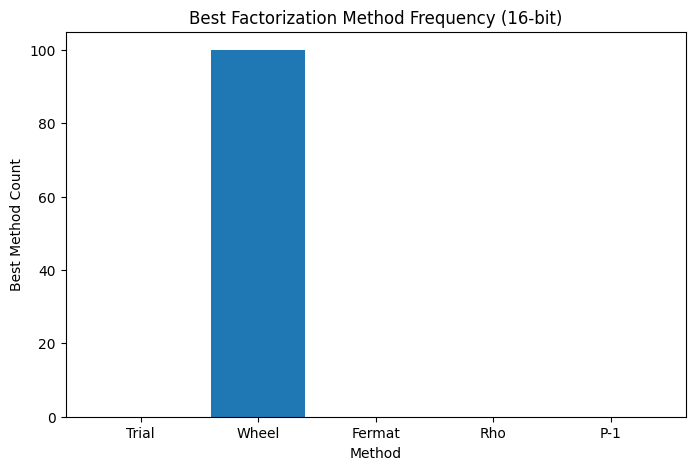

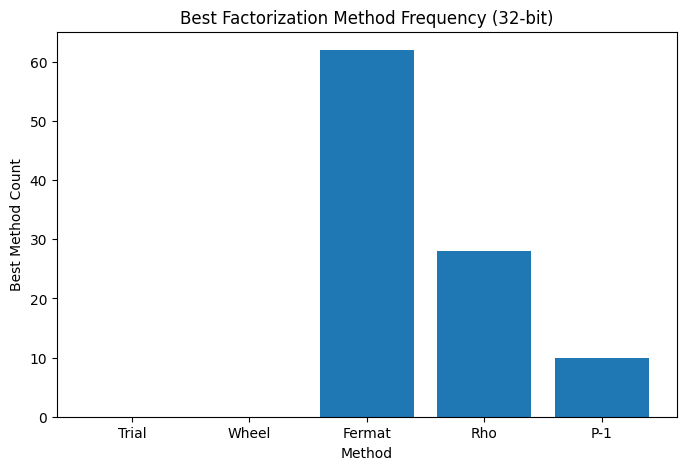

In [31]:
# ======================================================
# MAIN
# ======================================================


if __name__ == "__main__":
    print("Training PPO agent for 16-bit...")
    model_16_bit = train_agent(total_timesteps=50_000, bits=16)
    print("\nEvaluating 16-bit agent...")
    evaluate(model_16_bit, episodes=100, bits=16)

    print("\nTraining PPO agent for 32-bit...")
    model_32_bit = train_agent(total_timesteps=100_000, bits=32) # Increased timesteps for larger bit size
    print("\nEvaluating 32-bit agent...")
    evaluate(model_32_bit, episodes=100, bits=32)

    print("\nGenerating benchmark plots for 16-bit and 32-bit numbers...")
    benchmark_plot(bits=16)
    benchmark_plot(bits=32)